# Introducción

En esta práctica trabajaremos con **máquinas de vectores de soporte** o **SVM** (*Support Vector Machines*).

Las SVM son modelos supervisados que buscan una frontera de decisión que separe las clases con el mayor margen posible.

En esta práctica usaremos imágenes pequeñas de dígitos manuscritos.
El objetivo será distinguir entre dos dígitos que pueden confundirse visualmente:

- dígito **3**,
- dígito **8**.

Estudiaremos:

- margen,
- vectores soporte,
- parámetro de regularización `C`,
- kernels lineal y RBF,
- sensibilidad al escalado,
- sensibilidad a valores atípicos,
- visualización con PCA,
- comparación de métricas,
- y análisis de ejemplos mal clasificados.

La práctica está relacionada con los conceptos vistos en teoría:

- frontera de decisión,
- margen máximo,
- vectores soporte,
- margen blando,
- parámetro `C`,
- kernel trick,
- clasificación lineal y no lineal.

# Objetivos

Al finalizar esta práctica deberías ser capaz de:

- cargar y preparar un dataset real de imágenes,
- transformar imágenes en vectores de características,
- entrenar clasificadores SVM,
- comparar SVM lineal y SVM con kernel RBF,
- estudiar el efecto del escalado,
- interpretar el papel del parámetro `C`,
- interpretar el papel del parámetro `gamma`,
- identificar vectores soporte,
- estudiar el efecto de valores atípicos o ruido,
- visualizar datos en dos componentes principales,
- evaluar modelos usando varias métricas.

# Dataset: Digits

Trabajaremos con el dataset **Digits**, incluido en `scikit-learn`.

Este dataset contiene imágenes de dígitos manuscritos de tamaño 8 × 8 píxeles.

Cada imagen se representa mediante 64 variables numéricas:

- cada variable corresponde a la intensidad de un píxel,
- los valores representan niveles de gris,
- cada observación es una imagen convertida en un vector.

En esta práctica no usaremos todos los dígitos.
Seleccionaremos solo los ejemplos correspondientes a:

- `3`,
- `8`.

Así obtendremos un problema de clasificación binaria adecuado para estudiar SVM.

# Librerías necesarias

Ejecuta la siguiente celda.

In [21]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_digits

# División y validación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Preprocesamiento y pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos SVM
from sklearn.svm import SVC

# PCA
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    make_scorer
)

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (8, 6)

# Código de estudiante

## Ejercicio 1

Introduce tu código de estudiante.

Este código se usará como semilla aleatoria para que cada estudiante obtenga una partición entrenamiento/prueba ligeramente distinta.

In [22]:
CODIGO_ESTUDIANTE = 40

np.random.seed(CODIGO_ESTUDIANTE)

# Carga del dataset

## Ejercicio 2

Carga el dataset Digits usando `load_digits`.

```python
digits = load_digits()
```

Crea:

- una matriz de variables predictoras `X_all`,
- un vector de etiquetas `y_all`,
- una matriz de imágenes `imagenes_all`.

In [23]:
# COMPLETAR
digits = load_digits(as_frame=True)
X_all = digits.data
y_all = digits.target
imagenes_all = digits.images

## Ejercicio 3

Muestra:

- el número total de imágenes,
- el tamaño de cada imagen,
- el número de variables por imagen,
- las clases disponibles.

In [24]:
# COMPLETAR
print(f"Número total de imágenes: {X_all.shape[0]}")
print(f"Tamaño de cada imagen: {imagenes_all[0].shape}")
print(f"Número de variables por imagen: {X_all.shape[1]}")
print(f"Clases disponibles: {y_all.value_counts()}")

Número total de imágenes: 1797
Tamaño de cada imagen: (8, 8)
Número de variables por imagen: 64
Clases disponibles: target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64


# Selección del problema binario: dígito 3 frente a dígito 8

## Ejercicio 4

Selecciona solo los ejemplos correspondientes a los dígitos 3 y 8.

Crea:

- `X`,
- `y`,
- `imagenes`.

Codifica la clase como:

- `0` para el dígito 3,
- `1` para el dígito 8.

In [33]:
# COMPLETAR
filtro = y_all.isin([3, 8])

X = X_all[filtro]
y = y_all[filtro].apply(lambda x: 0 if x == 3 else 1)
imagenes = imagenes_all[filtro]

## Ejercicio 5

Muestra cuántas imágenes hay de cada clase.

Pregunta:

1. ¿Está el dataset aproximadamente balanceado?
2. ¿Por qué conviene mirar métricas distintas de la accuracy?

In [34]:
# COMPLETAR
print(f"Imagenes por clase: {y.value_counts()}")

Imagenes por clase: target
0    183
1    174
Name: count, dtype: int64


**Respuesta.**

1. Sí, está balanceado. Hay 183 imágenes del dígito 3 y 174 imágenes del dígito 8. Ambas clases tienen el mismo peso y representación en el conjunto de datos.
2. Porque el accuracy solo dice el porcentaje global de aciertos, pero oculta si el modelo comete un tipo de error específico, por ejemplo, si es peor reconociendo los ochos que los treses, o si confunde un dígito en particular.

# Visualización de imágenes

## Ejercicio 6

Representa algunas imágenes del dígito 3 y algunas imágenes del dígito 8.

Sugerencia:

- usa `plt.imshow(imagen, cmap="gray_r")`,
- elimina los ejes con `plt.axis("off")`.

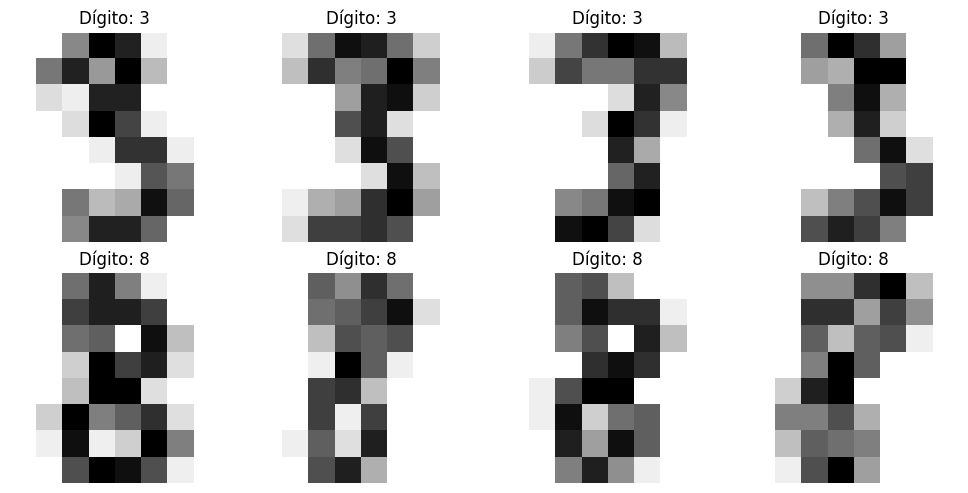

In [39]:
# COMPLETAR
indices_3 = [i for i, v in enumerate(y) if v == 0][:4]
indices_8 = [i for i, v in enumerate(y) if v == 1][:4]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i, idx in enumerate(indices_3 + indices_8):
    axes[i].imshow(imagenes[idx], cmap="gray_r")
    axes[i].axis("off")
    
    digito = 3 if i < 4 else 8
    axes[i].set_title(f"Dígito: {digito}")

plt.tight_layout()

## Ejercicio 7

Pregunta:

1. ¿Hay ejemplos visualmente ambiguos?
2. ¿Por qué puede ser difícil separar perfectamente los dígitos 3 y 8?
3. ¿Crees que una frontera lineal será suficiente?

**Respuesta.**

1. Si
2. Eso se debe a la baja calidad de las imagenes, ya que están a muy baja resolución 8x8 píxeles. 
3. No. Aunque un clasificador lineal puede alcanzar un acierto alto, fallará con los casos ambiguos. Debido a la naturaleza no lineal y a las variaciones del trazo, se necesita un modelo con fronteras curvas o ramificadas para delimitar con precisión las zonas donde ambos dígitos se solapan.

# División entrenamiento/prueba

## Ejercicio 8

Divide los datos en:

- entrenamiento (80%),
- prueba (20%).

Usa:

- `random_state = CODIGO_ESTUDIANTE`,
- `stratify = y`.

In [40]:
# COMPLETAR
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=CODIGO_ESTUDIANTE,
    stratify=y
)

# SVM lineal sin escalado

## Ejercicio 9

Entrena un modelo SVM lineal sin escalar las variables.

Usa:

- `SVC(kernel="linear")`,
- `C = 1`.

In [44]:
# COMPLETAR
svm1 = SVC(kernel="linear", C=1, random_state=CODIGO_ESTUDIANTE)
svm1.fit(X_train, y_train)
y_pred = svm1.predict(X_test)
y_probs = svm1.decision_function(X_test)

## Ejercicio 10

Evalúa el modelo calculando:

- accuracy,
- precision,
- recall,
- F1-score,
- AUC.

En esta práctica considera como clase positiva el dígito **8**.

In [46]:
# COMPLETAR
accuracy1 = accuracy_score(y_test, y_pred)
precision1 = precision_score(y_test, y_pred)
recall1 = recall_score(y_test, y_pred)
f11 = f1_score(y_test, y_pred)
auc1 = roc_auc_score(y_test, y_probs)

print(f"Accuracy: {accuracy1:.4f}")
print(f"Precision: {precision1:.4f}")
print(f"Recall: {recall1:.4f}")
print(f"F1-score: {f11:.4f}")
print(f"AUC: {auc1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
AUC: 1.0000


## Ejercicio 11

Construye la matriz de confusión del modelo SVM lineal sin escalado.

Pregunta:

1. ¿Cuántos dígitos 8 se clasifican incorrectamente como 3?
2. ¿Cuántos dígitos 3 se clasifican incorrectamente como 8?
3. ¿Qué tipo de confusión parece más frecuente?

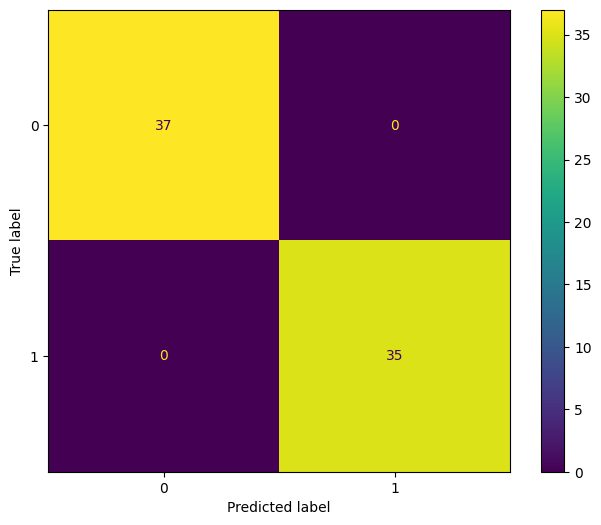

In [47]:
# COMPLETAR
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm)

cmd.plot()
plt.show()

**Respuesta.**

1. Ninguno (0). Al tener un Recall de 1.0000 para la clase positiva, significa que el modelo clasifica correctamente el 100% de los ochos. No ha habido ningún falso negativo.
2. Ninguno (0). Al tener una Precision de 1.0000, significa que cada vez que el modelo afirmó que una imagen era un 8, acertó por completo. No ha habido ningún falso positivo.
3. En este conjunto de test específico no existe ningún tipo de confusión, ya que el error es cero.

# Efecto del escalado

## Ejercicio 12

Entrena ahora una SVM lineal con escalado usando un `Pipeline` con:

- `StandardScaler`,
- `SVC(kernel="linear", C=1)`.

Compara los resultados con el modelo sin escalado.

In [50]:
# COMPLETAR
svm2 = SVC(kernel="linear", C=1, random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("escalado", StandardScaler()), ("svm2", svm2)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.decision_function(X_test)

In [51]:
accuracy2 = accuracy_score(y_test, y_pred)
precision2 = precision_score(y_test, y_pred)
recall2 = recall_score(y_test, y_pred)
f12 = f1_score(y_test, y_pred)
auc2 = roc_auc_score(y_test, y_probs)

print(f"Accuracy: {accuracy2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall: {recall2:.4f}")
print(f"F1-score: {f12:.4f}")
print(f"AUC: {auc2:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
AUC: 1.0000


## Ejercicio 13

Pregunta:

1. ¿Mejora el modelo al escalar?
2. ¿Por qué las SVM suelen ser sensibles al escalado?
3. En este dataset, ¿tiene sentido escalar aunque todos los píxeles estén en la misma escala original?

**Respuesta.**

1. No, las métricas son las mismas.
2. Porque dependen del cálculo de distancias entre los puntos para encontrar el hiperplano con el máximo margen de separación. Si una variable tiene un rango de valores enorme y otra tiene un rango muy pequeño, la variable con magnitudes grandes dominará el cálculo de la distancia.
3. No tiene mucho sentido práctico, pero sí teórico como buena costumbre, porque no altera nada.

# Vectores soporte

## Ejercicio 14

Obtén el número de vectores soporte del modelo SVM lineal con escalado.

Sugerencia:

- accede al modelo SVM dentro del `Pipeline`,
- usa `n_support_`.

In [53]:
# COMPLETAR
vectores = pipeline.named_steps["svm2"].n_support_
print(f"Vectores de soporte para la Clase 0 (3): {vectores[0]}")
print(f"Vectores de soporte para la Clase 1 (8): {vectores[1]}")
print(f"Número total de vectores de soporte: {vectores.sum()}")

Vectores de soporte para la Clase 0 (3): 17
Vectores de soporte para la Clase 1 (8): 14
Número total de vectores de soporte: 31


## Ejercicio 15

Representa algunas imágenes que sean vectores soporte.

Sugerencia:

- usa `support_` sobre el modelo SVM interno,
- recuerda que los índices corresponden al conjunto de entrenamiento.

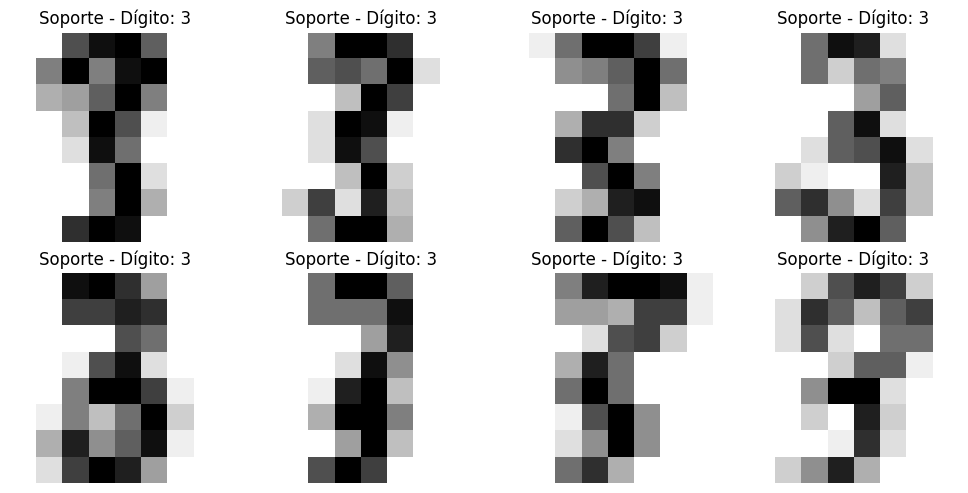

In [54]:
# COMPLETAR
indices_vectores = pipeline.named_steps["svm2"].support_

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i, idx in enumerate(indices_vectores[:8]):
    axes[i].imshow(X_train.iloc[idx].values.reshape(8, 8), cmap="gray_r")
    axes[i].axis("off")

    clase_real = y_train.iloc[idx]
    digito = 3 if clase_real == 0 else 8
    axes[i].set_title(f"Soporte - Dígito: {digito}")

plt.tight_layout()

## Ejercicio 16

Pregunta:

1. ¿Qué son los vectores soporte?
2. ¿Por qué son importantes para definir la frontera de decisión?
3. ¿Parecen visualmente más ambiguos que otros ejemplos?

**Respuesta.**

1. Son los puntos del conjunto de entrenamiento que se encuentran más cerca del hiperplano de separación o que llegan a violar el margen de seguridad.
2. Porque el modelo depende de ellos. Si eliminamos todos los demás puntos del dataset de entrenamiento y volvieramos a entrenar SVM, la frontera de decisión final y el hiperplano quedarían exactamente en el mismo sitio. Sostienen y dan forma al margen máximo de separación.
3. Sí, por lo general se aprecian mucho más ambiguos y deformes. El algoritmo selecciona estas imágenes precisamente porque se encuentran en la zona de conflicto.

# Efecto del parámetro C

## Ejercicio 17

Entrena varios modelos SVM lineales con escalado usando:

$$
C \in \{0.01, 0.1, 1, 10, 100\}
$$

Para cada valor calcula:

- accuracy en entrenamiento,
- accuracy en prueba,
- F1-score en prueba,
- número total de vectores soporte.

In [63]:
# COMPLETAR
C_vals = [0.01, 0.1, 1, 10, 100]

res = []

for C in C_vals:
    model = SVC(kernel="linear", C=C, random_state=CODIGO_ESTUDIANTE)
    pipeline = Pipeline(steps=[("escalado", StandardScaler()), ("svm", model)])
    
    pipeline.fit(X_train, y_train)
    total_vectores = pipeline.named_steps['svm'].n_support_.sum()
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    
    res.append({
        "C": C,
        "Acc Train": acc_train,
        "Acc Test": acc_test,
        "F1 Test": f1_test,
        "Total Vectores": total_vectores
    })

res = pd.DataFrame(res)
display(res)

,C,Acc Train,Acc Test,F1 Test,Total Vectores
0,0.01,0.996491,1.0,1.0,72
1,0.10,1.000000,1.0,1.0,30
2,1.00,1.000000,1.0,1.0,31
3,10.00,1.000000,1.0,1.0,31
4,100.00,1.000000,1.0,1.0,31


## Ejercicio 18

Representa gráficamente:

- accuracy de entrenamiento frente a `C`,
- accuracy de prueba frente a `C`.

Usa escala logarítmica en el eje horizontal.

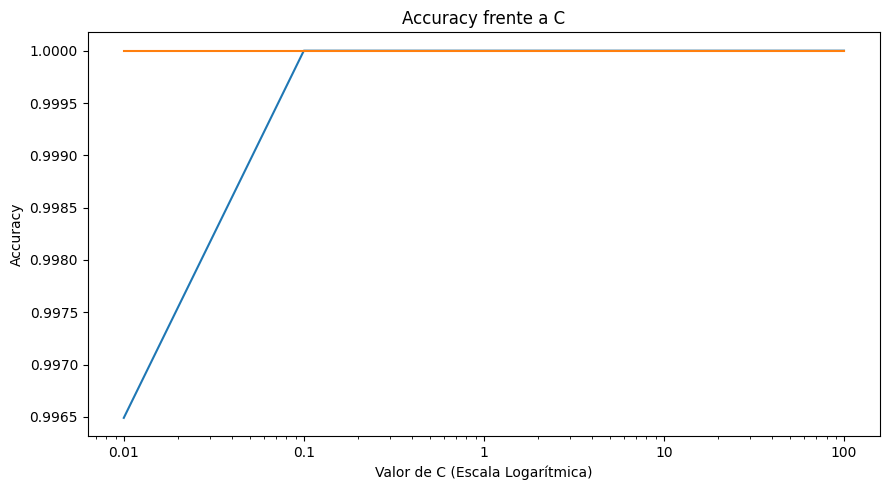

In [66]:
# COMPLETAR
plt.figure(figsize=(9, 5))
plt.plot(C_vals, res["Acc Train"])
plt.plot(C_vals, res["Acc Test"])
plt.xscale("log")
plt.title("Accuracy frente a C")
plt.xlabel("Valor de C (Escala Logarítmica)")
plt.ylabel("Accuracy")
plt.xticks(C_vals, labels=[str(c) for c in C_vals]) 
plt.tight_layout()
plt.show()

## Ejercicio 19

Pregunta:

1. ¿Qué ocurre cuando `C` es muy pequeño?
2. ¿Qué ocurre cuando `C` es muy grande?
3. ¿Cómo se relaciona `C` con la idea de margen blando?

**Respuesta.**

1. El modelo es muy permisivo con los errores. Prioriza conseguir una frontera suave y un margen lo más ancho posible, tolerando que haya datos mal clasificados o metidos dentro del canal de separación. Como el margen es muy amplio, el número de vectores soporte se dispara, ya que muchísimos puntos quedan dentro o cruzando el margen. Existe riesgo de underfitting.
2. El modelo se vuelve estricto. Penaliza cualquier error de clasificación, obligando a la frontera a ajustarse de forma milimétrica para dejar cada punto en su lado correcto. El margen de separación se vuelve muy estrecho y el número de vectores soporte cae drásticamente, reduciéndose solo a los pocos puntos indispensables pegados a la línea. Existe riesgo de overfitting.
3. Regula el margen blando. C es el peso que se da al penalizar esos errores: C bajo = poca importancia al error, el margen se ablanda al máximo. C alto = máxima importancia al error, el margen se endurece e intenta comportarse como un margen duro.

# Kernel RBF

## Ejercicio 20

Entrena una SVM con kernel RBF usando:

- `StandardScaler`,
- `SVC(kernel="rbf", C=1, gamma="scale")`.

Evalúa el modelo con las mismas métricas anteriores.

In [77]:
# COMPLETAR
svm3 = SVC(kernel="rbf", C=1, gamma="scale", random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("escalado", StandardScaler()), ("svm3", svm3)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.decision_function(X_test)

In [74]:
accuracy3 = accuracy_score(y_test, y_pred)
precision3 = precision_score(y_test, y_pred)
recall3 = recall_score(y_test, y_pred)
f13 = f1_score(y_test, y_pred)
auc3 = roc_auc_score(y_test, y_probs)

print(f"Accuracy: {accuracy3:.4f}")
print(f"Precision: {precision3:.4f}")
print(f"Recall: {recall3:.4f}")
print(f"F1-score: {f13:.4f}")
print(f"AUC: {auc3:.4f}")

Accuracy: 0.9722
Precision: 1.0000
Recall: 0.9429
F1-score: 0.9706
AUC: 1.0000


## Ejercicio 21

Compara la SVM lineal con la SVM RBF.

Pregunta:

1. ¿Cuál obtiene mejor F1-score?
2. ¿Cuál obtiene mejor AUC?
3. ¿Crees que para distinguir 3 y 8 puede ayudar una frontera no lineal?

**Respuesta.**

1. El lineal, ya que éste ha obtenido un f1 de 0.97. Se le ha escapado algunos 8 clasificándolos como 3.
2. Ambos obtienen un AUC de 1
3. Teóricamente sí debería ayudar, pero en este dataset específico no es necesario e incluso resulta contraproducente.

# Efecto del parámetro gamma

## Ejercicio 22

Entrena modelos SVM RBF con distintos valores de `gamma`:

$$
\gamma \in \{0.001, 0.01, 0.1, 1, 10\}
$$

Usa `C = 1`.

Calcula:

- accuracy en entrenamiento,
- accuracy en prueba,
- F1-score en prueba.

In [78]:
# COMPLETAR
gamma_vals = [0.001, 0.01, 0.1, 1, 10]

res = []

for gamma in gamma_vals:
    model = SVC(kernel="rbf", C=1, gamma=gamma, random_state=CODIGO_ESTUDIANTE)
    pipeline_rbf = Pipeline(steps=[("escalado", StandardScaler()),("svm", model)])
    
    pipeline_rbf.fit(X_train, y_train)
    y_pred_train = pipeline_rbf.predict(X_train)
    y_pred_test = pipeline_rbf.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    
    res.append({
        "Gamma": gamma,
        "Acc Train": acc_train,
        "Acc Test": acc_test,
        "F1 Test": f1_test
    })

res = pd.DataFrame(res)
display(res)

,Gamma,Acc Train,Acc Test,F1 Test
0,0.001,0.975439,1.000000,1.000000
1,0.010,1.000000,0.972222,0.970588
2,0.100,1.000000,0.944444,0.945946
3,1.000,1.000000,0.513889,0.000000
4,10.000,1.000000,0.513889,0.000000


## Ejercicio 23

Representa gráficamente el F1-score frente a `gamma`.

Usa escala logarítmica en el eje horizontal.

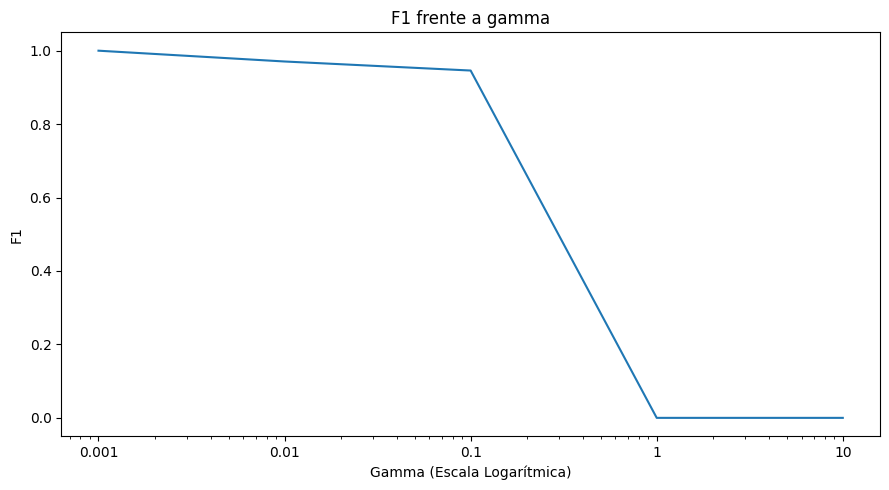

In [80]:
# COMPLETAR
plt.figure(figsize=(9, 5))
plt.plot(gamma_vals, res["F1 Test"])
plt.xscale("log")
plt.title("F1 frente a gamma")
plt.xlabel("Gamma (Escala Logarítmica)")
plt.ylabel("F1")
plt.xticks(gamma_vals, labels=[str(c) for c in gamma_vals]) 
plt.tight_layout()
plt.show()

## Ejercicio 24

Pregunta:

1. ¿Qué ocurre con valores muy pequeños de `gamma`?
2. ¿Qué ocurre con valores muy grandes de `gamma`?
3. ¿Por qué valores grandes de `gamma` pueden producir sobreajuste?

**Respuesta.**

1. El radio de influencia de cada vector de soporte es amplio. Esto significa que el modelo considera que los puntos individuales tienen un impacto que se extiende a gran distancia en el espacio de características. Como resultado, la frontera de decisión se vuelve muy suave, plana y casi lineal. Si es demasiado bajo, el modelo carecerá de la flexibilidad necesaria para capturar patrones complejos, lo que puede provocar underfitting.
2. El radio de influencia de cada punto se vuelve pequeño. El modelo solo permite que un punto afecte a su vecindario más inmediato. Visualmente, la frontera de decisión deja de ser una curva continua y se transforma en una serie de "islas" o contornos cerrados y muy ajustados alrededor de cada ejemplo de entrenamiento. La precisión en el conjunto de entrenamiento alcanzará el 100%, pero el rendimiento en el conjunto de prueba caerá drásticamente.
3. Producen overfitting porque el modelo pierde por la capacidad de generalizar. Al tener un radio de influencia pequeño, el algoritmo se obsesiona con memorizar la posición exacta de cada dato del conjunto de entrenamiento.

# Validación cruzada

## Ejercicio 25

Usa validación cruzada de 5 particiones para comparar:

- SVM lineal con escalado,
- SVM RBF con escalado.

Usa como métrica el F1-score.

In [83]:
# COMPLETAR
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=CODIGO_ESTUDIANTE)
model = SVC(kernel="linear", C=1, random_state=CODIGO_ESTUDIANTE)
pipeline_lineal = Pipeline(steps=[("escalado", StandardScaler()),("svm", model)])

model = SVC(kernel="rbf", C=1, gamma="scale", random_state=CODIGO_ESTUDIANTE)
pipeline_rbf = Pipeline(steps=[("escalado", StandardScaler()),("svm", model)])

scores_lineal = cross_val_score(pipeline_lineal, X, y, cv=cv, scoring="f1").mean()
scores_rbf = cross_val_score(pipeline_rbf, X, y, cv=cv, scoring="f1").mean()

print(f"F1 lineal: {scores_lineal}")
print(f"F1 rbf: {scores_rbf}")

F1 lineal: 0.9888106416275431
F1 rbf: 0.9857451900948172


## Ejercicio 26

Pregunta:

1. ¿Qué modelo obtiene mejor F1 medio?
2. ¿Qué modelo parece más estable?
3. ¿Por qué es útil la validación cruzada?

**Respuesta.**

1. El modelo SVM Lineal. Aunque la diferencia es pequeña, demuestra que trazar un hiperplano recto y directo en el espacio de 64 dimensiones de este dataset es ligeramente más efectivo para clasificar los treses y ochos que curvar la frontera de decisión con el kernel RBF.
2. El modelo SVM Lineal. Al ser un modelo más simple, sus predicciones varían menos de una partición a otra. Los modelos lineales son menos propensos a sufrir variaciones drásticas frente a pequeños cambios en los datos de entrenamiento.
3. Elimina el factor "suerte" del split inicial. Proporciona una métrica real y robusta: Al entrenar y evaluar el modelo varias veces en diferentes combinaciones de datos. Mide la estabilidad (Varianza): Al permitirnos calcular la desviación estándar de los aciertos entre las distintas particiones, nos dice si el modelo es consistente o si su rendimiento es caótico y depende demasiado de los datos concretos con los que se entrena.

# Visualización con PCA

Para visualizar la frontera de decisión necesitamos reducir el espacio de 64 píxeles a dos dimensiones.

Usaremos PCA para proyectar las imágenes sobre dos componentes principales.

Estos modelos 2D se usan para visualizar conceptos.
No necesariamente serán mejores que los modelos entrenados con los 64 píxeles originales.

## Ejercicio 27

Aplica PCA con dos componentes principales a los datos escalados.

Crea:

- `pca`,
- `X_pca`.

Muestra la varianza explicada por PC1 y PC2.

In [86]:
# COMPLETAR
pca = PCA(n_components=2, random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("escalado", StandardScaler()), ("pca", pca)])
X_pca = pipeline.fit_transform(X)
varianza_explicada = pipeline.named_steps["pca"].explained_variance_ratio_

print(f"PC1: {varianza_explicada[0]*100:.2f}% de la información")
print(f"PC2: {varianza_explicada[1]*100:.2f}% de la información")
print(f"Varianza Total Capturada: {varianza_explicada.sum()*100:.2f}% del total")

PC1: 15.84% de la información
PC2: 10.34% de la información
Varianza Total Capturada: 26.19% del total


## Ejercicio 28

Representa los datos proyectados sobre PC1 y PC2, coloreando por la clase real.

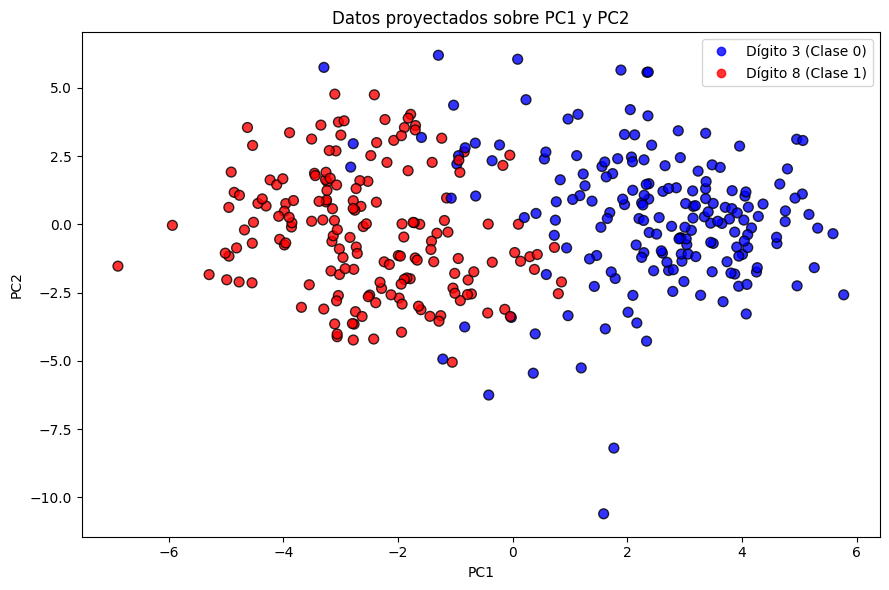

In [88]:
# COMPLETAR
plt.figure(figsize=(9, 6))

dispersion = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=y, 
    cmap="bwr", 
    alpha=0.8, 
    edgecolors="k", 
    s=50
)

leyenda = plt.legend(
    handles=dispersion.legend_elements()[0], 
    labels=["Dígito 3 (Clase 0)", "Dígito 8 (Clase 1)"],
    fontsize=10
)

plt.title("Datos proyectados sobre PC1 y PC2")
plt.xlabel("PC1", fontsize=10)
plt.ylabel("PC2", fontsize=10)
plt.tight_layout()
plt.show()

## Ejercicio 29

Entrena dos modelos en el plano PCA:

- SVM lineal,
- SVM RBF.

Ambos deben usar las dos componentes principales como variables.

In [89]:
# COMPLETAR
svm_lineal_pca = SVC(kernel="linear", C=1, random_state=CODIGO_ESTUDIANTE)
svm_rbf_pca = SVC(kernel="rbf", C=1, gamma="scale", random_state=CODIGO_ESTUDIANTE)

svm_lineal_pca.fit(X_pca, y)
svm_rbf_pca.fit(X_pca, y)

pred_lineal = svm_lineal_pca.predict(X_pca)
pred_rbf = svm_rbf_pca.predict(X_pca)

acc_lineal = accuracy_score(y, pred_lineal)
acc_rbf = accuracy_score(y, pred_rbf)

print(f"Accuracy de SVM Lineal en plano PCA: {acc_lineal:.4f}")
print(f"Accuracy de SVM RBF en plano PCA: {acc_rbf:.4f}")

Accuracy de SVM Lineal en plano PCA: 0.9216
Accuracy de SVM RBF en plano PCA: 0.9384


## Ejercicio 30

Representa la frontera de decisión de ambos modelos en el plano PCA.

Sugerencia:

- crea una malla de puntos con `np.meshgrid`,
- aplica el modelo sobre la malla,
- usa `contourf` para representar las regiones de decisión,
- representa encima los puntos reales.

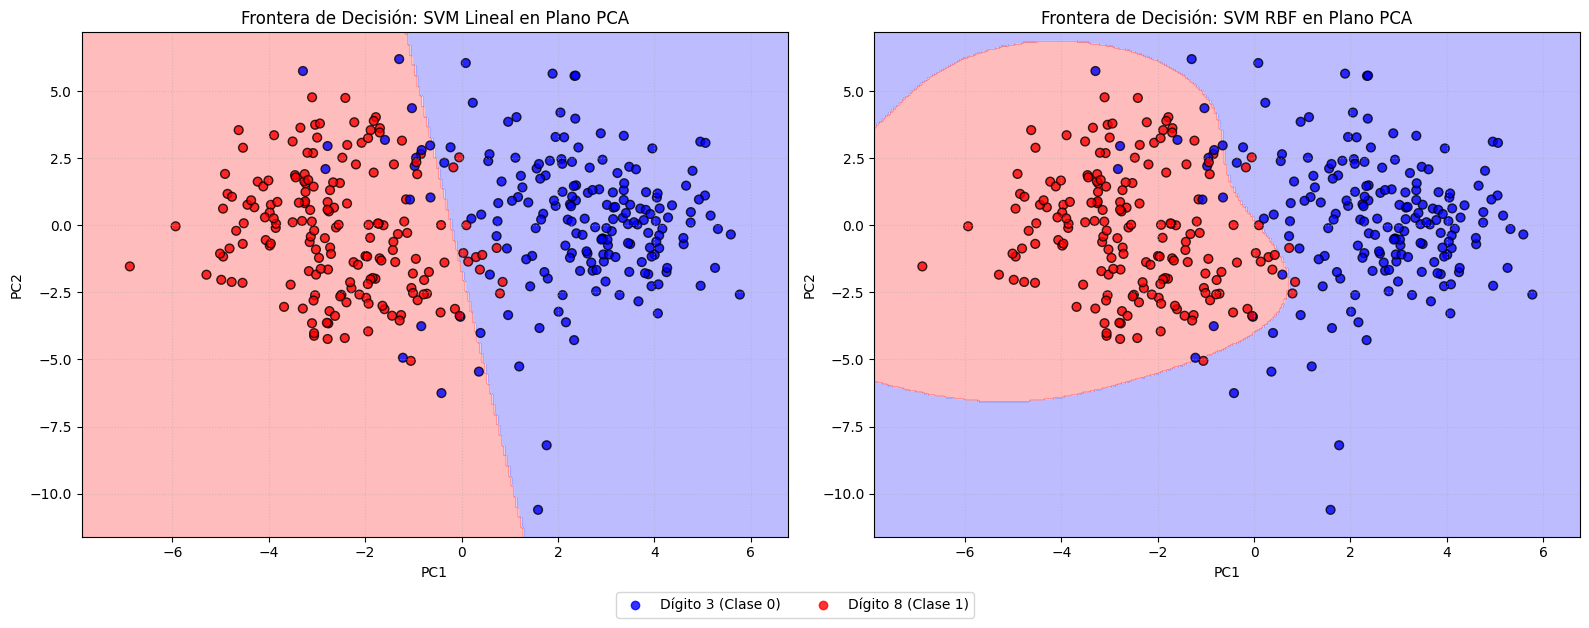

In [ ]:
# COMPLETAR
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

puntos_malla = np.c_[xx.ravel(), yy.ravel()]

Z_lineal = svm_lineal_pca.predict(puntos_malla)
Z_rbf = svm_rbf_pca.predict(puntos_malla)

Z_lineal = Z_lineal.reshape(xx.shape)
Z_rbf = Z_rbf.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].contourf(xx, yy, Z_lineal, alpha=0.3, cmap="bwr")
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="bwr", alpha=0.8, edgecolors="k", s=40)
axes[0].set_title("Frontera de Decisión: SVM Lineal en Plano PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, linestyle=":", alpha=0.5)

axes[1].contourf(xx, yy, Z_rbf, alpha=0.3, cmap="bwr")
scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="bwr", alpha=0.8, edgecolors="k", s=40)
axes[1].set_title("Frontera de Decisión: SVM RBF en Plano PCA")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, linestyle=":", alpha=0.5)
fig.legend(handles=scatter0.legend_elements()[0], 
           labels=["Dígito 3 (Clase 0)", "Dígito 8 (Clase 1)"], 
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

## Ejercicio 31

Pregunta:

1. ¿Qué diferencia observas entre la frontera lineal y la frontera RBF?
2. ¿Cuál parece más flexible?
3. ¿Por qué una frontera más flexible no siempre implica mejor generalización?
4. ¿Qué información se pierde al reducir de 64 variables a 2 componentes?

**Respuesta.**

1. La frontera lineal es una línea recta rígida que corta el plano de forma matemática directa. Divide el espacio en dos mitades exactas sin importar la distribución sinuosa de los puntos. La frontera RBF es una curva sinuosa, orgánica y adaptativa. Es capaz de rodear y ceñirse a la silueta real de las nubes de datos, creando transiciones suaves e incluso rodeando zonas complejas.
2. El modelo SVM RBF es el más flexible. Gracias a la proyección matemática implícita del kernel trick, no está encadenado a la rigidez de una recta. Puede curvarse tanto como le exijan los hiperparámetros ($C$ y $\gamma$) para esquivar errores y amoldarse a la topología de los datos.
3. Porque una frontera flexible corre el riesgo de sufrir overfitting.
4. Se descarta aproximadamente el 80% - 85% de la varianza original del dataset.

# Análisis de errores

## Ejercicio 32

Identifica algunos ejemplos mal clasificados por el mejor modelo que hayas obtenido.

Representa sus imágenes reales junto con:

- clase real,
- clase predicha.

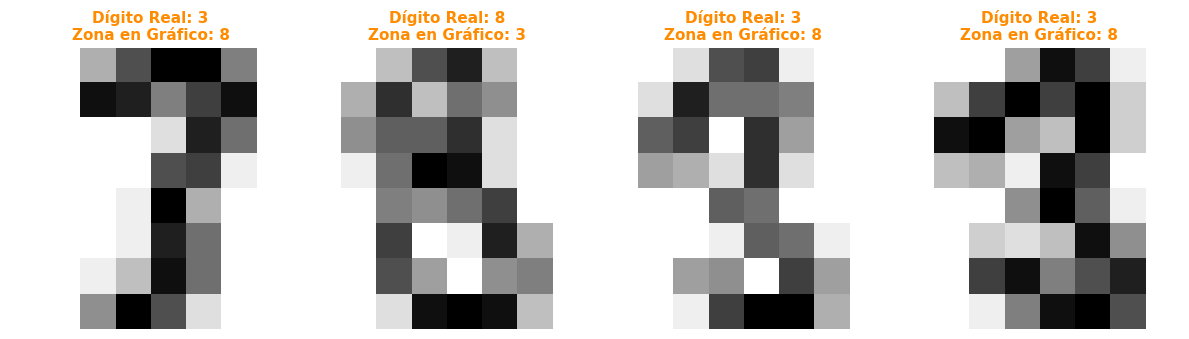

In [93]:
# COMPLETAR
modelo_pca_a_analizar = svm_lineal_pca 
y_pred_pca = modelo_pca_a_analizar.predict(X_pca)
y_real_np = np.array(y)
indices_infiltrados = np.where(y_pred_pca != y_real_np)[0]

num_a_mostrar = min(4, len(indices_infiltrados))
fig, axes = plt.subplots(1, num_a_mostrar, figsize=(3 * num_a_mostrar, 3.5))

if num_a_mostrar == 1:
    axes = [axes]
        
for i, idx in enumerate(indices_infiltrados[:num_a_mostrar]):
    imagen_matriz = X.iloc[idx].values.reshape(8, 8)
    
    axes[i].imshow(imagen_matriz, cmap="gray_r")
    axes[i].axis("off")
        
    clase_real_cod = y_real_np[idx]
    clase_pred_cod = y_pred_pca[idx]
        
    digito_real = 3 if clase_real_cod == 0 else 8
    digito_pred = 3 if clase_pred_cod == 0 else 8
        
    axes[i].set_title(f"Dígito Real: {digito_real}\nZona en Gráfico: {digito_pred}", 
                          color="darkorange", fontsize=11, fontweight="bold")
        
plt.tight_layout()
plt.show()

## Ejercicio 33

Pregunta:

1. ¿Los errores son visualmente comprensibles?
2. ¿Hay dígitos 3 que se parecen a un 8?
3. ¿Hay dígitos 8 que se parecen a un 3?

**Respuesta.**

1. Algunos si, cuesta diferenciar a simple vista si es un 8 o un 3
2. Si
3. Si

# Sensibilidad a valores atípicos o ruido

## Ejercicio 34

Crea una copia del conjunto de entrenamiento e introduce ruido artificial en algunas imágenes.

Por ejemplo:

- selecciona algunos ejemplos,
- cambia aleatoriamente varios píxeles,
- o añade ruido gaussiano a las intensidades.

Después, entrena una SVM lineal con `C=1` antes y después de introducir ruido.

In [94]:
# COMPLETAR
X_train_ruido = X_train.copy()

media = 0
desviacion_estandar = 3.5  

ruido_gaussiano = np.random.normal(media, desviacion_estandar, X_train_ruido.shape)

X_train_ruido = X_train_ruido + ruido_gaussiano
X_train_ruido = np.clip(X_train_ruido, 0, 16)

def crear_pipeline():
    return Pipeline(steps=[
        ("escalado", StandardScaler()),
        ("svm", SVC(kernel="linear", C=1, random_state=CODIGO_ESTUDIANTE))
    ])

pipeline_limpio = crear_pipeline()
pipeline_ruidoso = crear_pipeline()

pipeline_limpio.fit(X_train, y_train)
y_pred_limpio = pipeline_limpio.predict(X_test)
acc_limpio = accuracy_score(y_test, y_pred_limpio)
f1_limpio = f1_score(y_test, y_pred_limpio)

pipeline_ruidoso.fit(X_train_ruido, y_train)
y_pred_ruidoso = pipeline_ruidoso.predict(X_test)
acc_ruidoso = accuracy_score(y_test, y_pred_ruidoso)
f1_ruidoso = f1_score(y_test, y_pred_ruidoso)

## Ejercicio 35

Compara los resultados antes y después de introducir ruido.

Pregunta:

1. ¿Empeora el rendimiento?
2. ¿Cambia el número de vectores soporte?
3. ¿Por qué las SVM pueden ser sensibles a puntos difíciles o ruidosos?

In [95]:
# COMPLETAR
print(f"Modelo original (Entrenado con datos limpios):")
print(f"  - Accuracy en Test: {acc_limpio:.4f}")
print(f"  - F1-score en Test: {f1_limpio:.4f}")
print(f"\nModelo ruidoso (Entrenado con datos modificados):")
print(f"  - Accuracy en Test: {acc_ruidoso:.4f}")
print(f"  - F1-score en Test: {f1_ruidoso:.4f}")

Modelo original (Entrenado con datos limpios):
  - Accuracy en Test: 1.0000
  - F1-score en Test: 1.0000

Modelo ruidoso (Entrenado con datos modificados):
  - Accuracy en Test: 0.9722
  - F1-score en Test: 0.9714


**Respuesta.**

1. Sí, el rendimiento empeora de forma evidente. Al introducir ruido artificial en los datos de entrenamiento, el accuracy en el conjunto de test baja, y el F1-score también. Esto ocurre porque el ruido emborrona los bordes limpios de los números, haciendo que el modelo aprenda trazos deformados que no se corresponden con la realidad, provocando que cometa algunos fallos al evaluar las imágenes limpias de test.
2. Sí, el número de vectores de soporte aumenta. Al añadir ruido, muchos píxeles de fondo que antes eran totalmente blancos o muy oscuros ahora toman valores intermedios aleatorios. Esto rompe la separación limpia que existía entre las dos clases y provoca que una cantidad de puntos se desplacen hacia la zona central, quedando dentro del margen o cruzando la frontera.
3. Las SVM son especialmente sensibles al ruido debido a su propia naturaleza matemática: la frontera de decisión se construye basándose única y exclusivamente en los puntos más extremos, los vectores soporte.

# Comparación final de modelos

## Ejercicio 36

Construye una tabla resumen comparando al menos:

- SVM lineal sin escalado,
- SVM lineal con escalado,
- SVM RBF con escalado,
- mejor SVM lineal según `C`,
- mejor SVM RBF según `gamma`.

La tabla debe incluir:

- accuracy,
- precision,
- recall,
- F1-score,
- AUC.

In [96]:
# COMPLETAR
# COMPLETAR
res = pd.DataFrame(columns=["Algoritmo", "Accuracy", "Precision", "Recall", "F1-score", "AUC"])
res.loc[len(res)] = ["svm lineal sin escalad", accuracy1, precision1, recall1, f11, auc1]
res.loc[len(res)] = ["svm lineal con escalado", accuracy2, precision2, recall2, f12, auc2]
res.loc[len(res)] = ["svm rbf con escalado", accuracy3, precision3, recall3, f13, auc3]

display(res)

,Algoritmo,Accuracy,Precision,Recall,F1-score,AUC
0,svm lineal sin escalad,1.000000,1.0,1.000000,1.000000,1.0
1,svm lineal con escalado,1.000000,1.0,1.000000,1.000000,1.0
2,svm rbf con escalado,0.972222,1.0,0.942857,0.970588,1.0


## Ejercicio 37

Pregunta:

1. ¿Qué modelo elegirías finalmente?
2. ¿Qué métrica has priorizado?
3. ¿Qué importancia tiene el escalado?
4. ¿Qué ventajas e inconvenientes tiene usar un kernel RBF?

**Respuesta.**

1. Un modelo lineal con o sin escalado ya que obtiene todo 1
2. La f1-score ya que mide la media entre el recall y precision
3. Como svm depende de distancias, escalar los datos evita errores
4. Ventajas: Flexibilidad absoluta: puede proyectar los datos a una dimensión infinita de forma implícita, permitiéndole trazar fronteras de decisión curvas muy complejas y orgánicas. Problemas no lineales: Es indispensable cuando las clases están solapadas de manera sinuosa o cuando una clase rodea completamente a la otra, escenarios donde una línea recta jamás podría separar los datos.
   
   Inconvenientes:Riesgo de Sobreajuste (Overfitting): Al ser tan flexible, si no se sintoniza con cuidado el parámetro gamma, el modelo memorizará el ruido y los puntos extremos del entrenamiento, perdiendo capacidad de generalización en el test (como te ocurrió cuando bajó su rendimiento frente al lineal).Complejidad y Coste: Es mucho más lento de entrenar con millones de datos y requiere optimizar dos hiperparámetros a la vez ($C$ y $\gamma$) mediante técnicas lentas como GridSearchCV, a diferencia del modelo lineal que es directo.

# Ejercicio opcional: clasificación multiclase

Hasta ahora hemos trabajado con un problema binario: distinguir 3 frente a 8.

Como extensión opcional, entrena una SVM para clasificar todos los dígitos del 0 al 9.

Pregunta:

- ¿Qué cambia en la matriz de confusión?
- ¿Qué métricas usarías en un problema multiclase?
- ¿Qué dígitos se confunden más?

In [ ]:
# EJERCICIO OPCIONAL
# COMPLETAR


# Ejercicio final de reflexión

Responde brevemente a las siguientes preguntas.

1. ¿Qué significa maximizar el margen?
2. ¿Qué son los vectores soporte?
3. ¿Qué controla el parámetro `C`?
4. ¿Qué controla el parámetro `gamma` en el kernel RBF?
5. ¿Por qué las SVM son sensibles al escalado?
6. ¿Qué diferencia hay entre una SVM lineal y una SVM RBF?
7. ¿Por qué los ejemplos ambiguos o ruidosos pueden afectar a la frontera de decisión?
8. ¿Qué ventajas tiene usar imágenes de dígitos para estudiar SVM?

**Respuesta.**

1. Maximizar el margen significa encontrar la distancia máxima de seguridad entre la frontera de decisión (el hiperplano que separa las clases) y los puntos más cercanos de cada una de ellas.
2. Son los puntos de entrenamiento críticos que se encuentran justo en el borde del margen de separación. Son los elementos más difíciles o ambiguos del dataset.
3. Se encarga de regular el equilibrio entre el ancho del margen y los errores de clasificación (margen blando).
4. Define el radio de influencia de cada vector de soporte individual.
5. Por el cálculo de distancias geométricas (euclidianas) entre los vectores para posicionar el hiperplano.
6. La diferencia radica en la geometría y complejidad de la frontera de decisión:La SVM lineal busca un corte totalmente recto y la SVM RBF utiliza el "truco del kernel" para proyectar implícitamente los datos a una dimensión superior donde sí se puedan separar mediante curvas.
7. Debido a que las SVM dependen de forma directa y exclusiva de los puntos extremos (vectores soporte) para trazar la frontera.
8. Tiene alta dimensionalidad comprensible: Cada imagen cuenta con 64 píxeles (características), lo que permite entender cómo trabaja un modelo en espacios multidimensionales, pero a la vez mantiene un tamaño lo bastante acotado para entrenar rapido. Permite la inspección visual directa: Cuando el modelo comete un error, se puede ver visualmente lo que falla. Es ideal para técnicas de reducción: Al aplicar PCA sobre este tipo de datos, se puede experimentar visualmente cómo se colapsa la información de los píxeles en un plano cartesiano 2D, permitiendo dibujar mapas explícitos de las fronteras de decisión y las regiones de clasificación.

# Entrega

La entrega debe incluir:

- el notebook completado,
- todas las gráficas,
- las tablas de métricas,
- las respuestas razonadas,
- y la interpretación de resultados.

No basta con ejecutar código: las respuestas deben explicar qué significan los resultados obtenidos.

# Comentario sobre el código de estudiante

Todos los estudiantes trabajarán con el mismo dataset completo, pero usarán distintos valores de `random_state` derivados de su código de estudiante.

Esto hace que:

- las particiones entrenamiento/prueba cambien ligeramente,
- los resultados numéricos no sean exactamente iguales,
- pero todos trabajen sobre el mismo problema y puedan compararse resultados.

Esta estrategia facilita:

- la corrección,
- la comparación en clase,
- y evita que algunos estudiantes reciban subconjuntos demasiado fáciles o difíciles.